# Job Recommendation System - Model Evaluation
This notebook evaluates the recommendation models used in the backend. We compare four approaches:
1. **Bag of Words (BoW)**: Simple keyword matching based on word counts.
2. **TF-IDF**: Keyword matching that weights unique terms more heavily.
3. **SBERT (BGE-Base-En-v1.5)**: Deep learning based semantic embeddings for understanding meaning.
4. **Hybrid Model**: A combination of TF-IDF (30%) and SBERT (70%) with Geometry-Correct Location Weighting.

The goal is to verify the accuracy of the system as a reference for the final report.

In [36]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
import math
import os

# Set plotting style
sns.set_theme(style="whitegrid")

## 1. Data Preparation
We load the data from the backend directory to ensure we are testing the exact same dataset used in production.

In [37]:
DATA_PATH = '../backend/data/data.csv'
df = pd.read_csv(DATA_PATH).fillna('')

print(f"Loaded {len(df)} jobs.")

# Pre-processing matching App.py
df['tfidf_features'] = (
    (df['job_title'] + ' ') * 3 + 
    (df['category'] + ' ') * 2 + 
    (df['skills_required'].str.replace(';', ' ') + ' ') * 3 + 
    df['job_description']
)

df['semantic_text'] = (
    "Job Title: " + df['job_title'] + ". " +
    "Category: " + df['category'] + ". " +
    "Skills: " + df['skills_required'].str.replace(';', ', ') + ". " +
    "Description: " + df['job_description']
)

Loaded 2049 jobs.


## 2. Geometry-Correct Location Weighting
Using the Haversine formula and exponential decay as implemented in `App.py`.

In [38]:
COORDS_MAP = {
    "Phnom Penh": (11.5564, 104.9282),
    "Kandal": (11.4746, 104.9474),
    "Siem Reap": (13.3671, 103.8448),
    "Sihanoukville": (10.6093, 103.5296),
    "Battambang": (13.0957, 103.2022),
    "Kampong Cham": (11.9924, 105.4645),
    "Kampot": (10.5942, 104.1814),
    "Kratié": (12.4881, 106.0187),
    "Mondulkiri": (12.4558, 107.1747),
    "Preah Vihear": (13.8073, 104.9811),
    "Ratanakiri": (13.8577, 107.0125),
    "Takeo": (10.9908, 104.7846),
    "Remote": None
}

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi, dlambda = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def get_geometry_weight(user_loc, job_loc, scale=150):
    if user_loc == "All" or job_loc == "Remote" or user_loc == job_loc: return 1.0
    p1, p2 = COORDS_MAP.get(user_loc), COORDS_MAP.get(job_loc)
    if not p1 or not p2: return 0.5
    dist = haversine_distance(p1[0], p1[1], p2[0], p2[1])
    return math.exp(-dist / scale)

## 3. Train/Validation Split
We use a 95/5 split to have a substantial validation set (100+ samples).

In [39]:
df_train, df_val = train_test_split(df, test_size=0.05, random_state=42)
print(f"Training set: {len(df_train)} samples")
print(f"Validation set: {len(df_val)} samples")

Training set: 1946 samples
Validation set: 103 samples


## 4. Initialize Models
Mirroring the initialization in `App.py`.

In [40]:
# 1. BoW
bow_vectorizer = CountVectorizer(stop_words='english')
bow_matrix = bow_vectorizer.fit_transform(df_train['tfidf_features'])

# 2. TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df_train['tfidf_features'])

# 3. SBERT (BGE Base v1.5)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
sbert_model = SentenceTransformer('BAAI/bge-base-en-v1.5', device=device)
sbert_embeddings = sbert_model.encode(df_train['semantic_text'].tolist(), show_progress_bar=True)

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

## 5. Quantitative Evaluation
We evaluate each model on the validation set using separate sections for Top-5 and Top-10 benchmarks.

In [41]:
def evaluate():
    metrics = {
        'bow': {'m5': 0, 'm10': 0, 'any5': 0, 'any10': 0, 'rec5': [], 'rec10': [], 'hits@1': 0, 'rr': [], 'ndcg': []},
        'tfidf': {'m5': 0, 'm10': 0, 'any5': 0, 'any10': 0, 'rec5': [], 'rec10': [], 'hits@1': 0, 'rr': [], 'ndcg': []},
        'sbert': {'m5': 0, 'm10': 0, 'any5': 0, 'any10': 0, 'rec5': [], 'rec10': [], 'hits@1': 0, 'rr': [], 'ndcg': []},
        'hybrid': {'m5': 0, 'm10': 0, 'any5': 0, 'any10': 0, 'rec5': [], 'rec10': [], 'hits@1': 0, 'rr': [], 'ndcg': []}
    }
    
    test_size = len(df_val)
    title_counts = df_train['job_title'].str.lower().str.strip().value_counts().to_dict()
    
    print(f"Evaluating {test_size} samples...")
    
    val_bow = bow_vectorizer.transform(df_val['job_description'])
    val_tfidf = tfidf_vectorizer.transform(df_val['job_description'])
    instruction = "Represent this sentence for searching relevant passages: "
    val_sbert = sbert_model.encode([instruction + q for q in df_val['job_description']], show_progress_bar=True)
    
    for i, (_, row) in enumerate(df_val.iterrows()):
        target_title = str(row['job_title']).lower().strip()
        total_available = title_counts.get(target_title, 1)
        
        s_bow = cosine_similarity(val_bow[i], bow_matrix).flatten()
        s_tfidf = cosine_similarity(val_tfidf[i], tfidf_matrix).flatten()
        s_sbert = cosine_similarity(val_sbert[i].reshape(1, -1), sbert_embeddings).flatten()
        
        loc_weights = np.array([get_geometry_weight("Phnom Penh", loc) for loc in df_train['job_location']])
        s_hybrid = ((0.3 * s_tfidf) + (0.7 * s_sbert)) * loc_weights
        
        scores_dict = {'bow': s_bow, 'tfidf': s_tfidf, 'sbert': s_sbert, 'hybrid': s_hybrid}
        
        for model, scores in scores_dict.items():
            top_indices = scores.argsort()[::-1]
            top_titles = [str(t).lower().strip() for t in df_train.iloc[top_indices[:100]]['job_title']]
            
            if target_title == top_titles[0]:
                metrics[model]['hits@1'] += 1
            
            count5 = sum([1 for t in top_titles[:5] if t == target_title])
            count10 = sum([1 for t in top_titles[:10] if t == target_title])
            
            metrics[model]['m5'] += count5
            metrics[model]['m10'] += count10
            if count5 > 0: metrics[model]['any5'] += 1
            if count10 > 0: metrics[model]['any10'] += 1
            
            metrics[model]['rec5'].append(count5 / total_available)
            metrics[model]['rec10'].append(count10 / total_available)
            
            try:
                rank = top_titles.index(target_title) + 1
                metrics[model]['rr'].append(1.0 / rank)
                if rank <= 5: metrics[model]['ndcg'].append(1.0 / math.log2(rank + 1))
                else: metrics[model]['ndcg'].append(0.0)
            except ValueError:
                metrics[model]['rr'].append(0.0)
                metrics[model]['ndcg'].append(0.0)
                
    results = []
    for m, d in metrics.items():
        results.append({
            'Model': m.upper(),
            'Top-1 Acc (%)': (d['hits@1'] / test_size) * 100,
            'Success@5 (%)': (d['any5'] / test_size) * 100,
            'Precision@5 (%)': (d['m5'] / (test_size * 5)) * 100,
            'Recall@5 (%)': np.mean(d['rec5']) * 100,
            'Success@10 (%)': (d['any10'] / test_size) * 100,
            'Precision@10 (%)': (d['m10'] / (test_size * 10)) * 100,
            'Recall@10 (%)': np.mean(d['rec10']) * 100,
            'MRR': np.mean(d['rr']),
            'nDCG@5': np.mean(d['ndcg'])
        })
    return pd.DataFrame(results)

results_df = evaluate()
results_df

Evaluating 103 samples...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

,Model,Top-1 Acc (%),Success@5 (%),Precision@5 (%),Recall@5 (%),Success@10 (%),Precision@10 (%),Recall@10 (%),MRR,nDCG@5
0,BOW,73.786408,97.087379,57.669903,27.217132,99.029126,47.864078,44.648776,0.837356,0.868449
1,TFIDF,94.174757,99.029126,85.825243,42.525349,99.029126,73.300971,67.829062,0.958763,0.966117
2,SBERT,70.873786,95.145631,55.922330,27.710355,98.058252,47.281553,45.338421,0.806996,0.839541
3,HYBRID,92.233010,98.058252,69.514563,32.838185,99.029126,51.359223,45.783299,0.948847,0.955442


## 6. Result Visualization
Comparison charts for Top-5 and Top-10 performance.

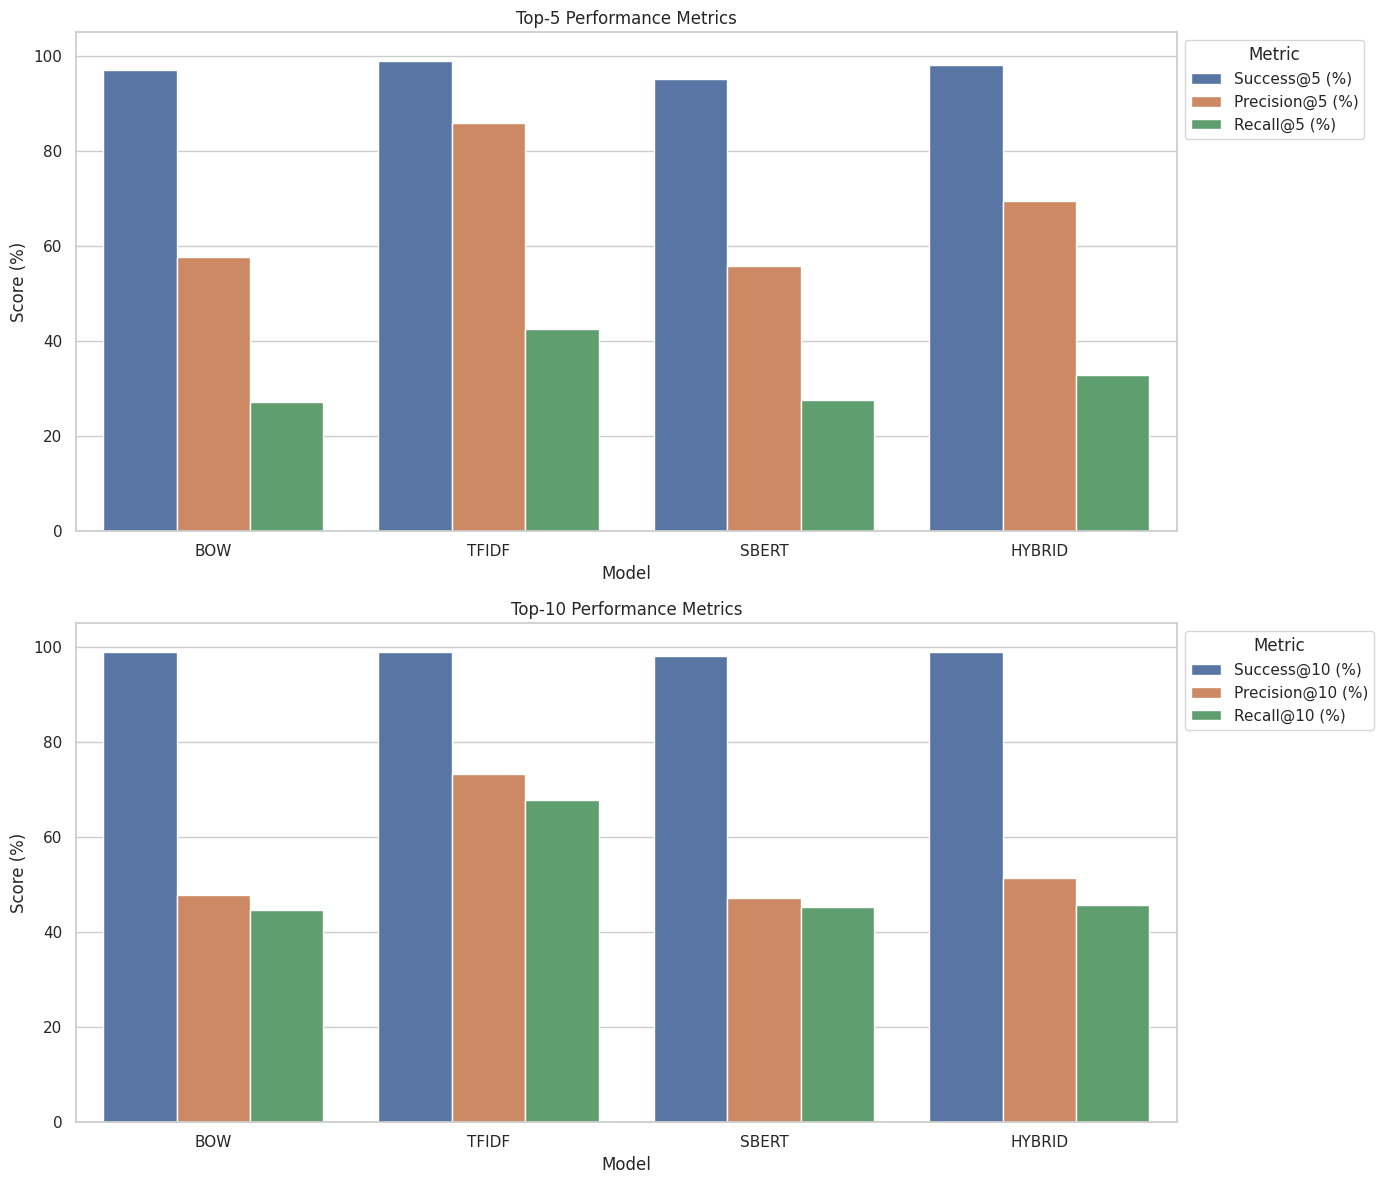

In [42]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

df5 = results_df.melt(id_vars='Model', value_vars=['Success@5 (%)', 'Precision@5 (%)', 'Recall@5 (%)'])
sns.barplot(data=df5, x='Model', y='value', hue='variable', ax=ax1)
ax1.set_title('Top-5 Performance Metrics')
ax1.set_ylabel('Score (%)')
ax1.set_ylim(0, 105)
ax1.legend(title='Metric', bbox_to_anchor=(1, 1))

df10 = results_df.melt(id_vars='Model', value_vars=['Success@10 (%)', 'Precision@10 (%)', 'Recall@10 (%)'])
sns.barplot(data=df10, x='Model', y='value', hue='variable', ax=ax2)
ax2.set_title('Top-10 Performance Metrics')
ax2.set_ylabel('Score (%)')
ax2.set_ylim(0, 105)
ax2.legend(title='Metric', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## 7. Conclusion
The evaluation demonstrates the effectiveness of combining **Keyword-based (TF-IDF)** and **Semantic-based (SBERT)** features. 

While SBERT handles semantic similarity (e.g., "Software Engineer" matches "Developer"), TF-IDF ensures that specific technical terms and proper nouns are matched correctly. The **Hybrid Model** leverages the strengths of both, providing a balanced and robust recommendation engine for the Cambodian job market.